In [ ]:
# 1. Create the data directory PyTorch expects
!mkdir -p ./data

# 2. Download the exact CIFAR-10 python tarball from a reliable academic mirror
!wget -c https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz -O ./data/cifar-10-python.tar.gz

# 3. Extract the tarball (this will create the 'cifar-10-batches-py' folder PyTorch needs)
!tar -xzf ./data/cifar-10-python.tar.gz -C ./data/

--2026-05-02 19:52:01--  https://data.brainchip.com/dataset-mirror/cifar10/cifar-10-python.tar.gz
Resolving data.brainchip.com (data.brainchip.com)... 146.59.209.152, 2001:41d0:301::31
Connecting to data.brainchip.com (data.brainchip.com)|146.59.209.152|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘./data/cifar-10-python.tar.gz’

./data/cifar-10-pyt 100%[===================>] 162.60M  11.2MB/s    in 16s     

2026-05-02 19:52:18 (10.3 MB/s) - ‘./data/cifar-10-python.tar.gz’ saved [170498071/170498071]



In [ ]:
from google.colab import drive
import mlflow
import os

from simple_model import SimpleCNN
from dataset import get_dataloader
import torch
import torch.optim as optim
import torch.nn as nn
import copy

# _____________________ Colab & MLflow Setup _________________________
# Mount Google Drive to save MLflow data persistently
drive.mount('/content/drive')

# Set MLflow tracking URI to a folder in your Drive
mlflow_dir = '/content/drive/MyDrive/CIFAR10_MLflow_Experiments'
os.makedirs(mlflow_dir, exist_ok=True)
mlflow.set_tracking_uri(f"file://{mlflow_dir}")
mlflow.set_experiment("CIFAR10_Augmentation_Combinations")

# _____________________ Device configuration _________________________
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ____________________________________________________
# Hyperparameters
# ____________________________________________________
NUM_EPOCHS    = 30
BATCH_SIZE    = 64
LEARNING_RATE = 0.001
WEIGHT_DECAY  = 0.0005
NUM_CLASSES   = 10

# ____________________________________________________
# Experiment settings - Uncomment ONE group per session
# ____________________________________________________
PERCENTAGES = [0.1, 0.25, 0.50, 1.0]

# GROUP 0: Baseline (1 combination * 4 percentages = 4 runs)
#ACTIVE_COMBINATIONS = [['none']]

# GROUP 1: 5C1 (5 combinations * 4 percentages = 20 runs)
#ACTIVE_COMBINATIONS = [
#     ['flip'], ['rotation'], ['color'], ['crop'], ['erasing']
# ]

# GROUP 2: 5C2 (10 combinations * 4 percentages = 40 runs)
# ACTIVE_COMBINATIONS = [
#     ['flip', 'rotation'], ['flip', 'color'], ['flip', 'crop'], ['flip', 'erasing'],
#     ['rotation', 'color'], ['rotation', 'crop'], ['rotation', 'erasing'],
#     ['color', 'crop'], ['color', 'erasing'],
#     ['crop', 'erasing']
# ]

# GROUP 3: 5C3 (10 combinations * 4 percentages = 40 runs)
# ACTIVE_COMBINATIONS = [
#     ['flip', 'rotation', 'color'], ['flip', 'rotation', 'crop'], ['flip', 'rotation', 'erasing'],
#     ['flip', 'color', 'crop'], ['flip', 'color', 'erasing'], ['flip', 'crop', 'erasing'],
#     ['rotation', 'color', 'crop'], ['rotation', 'color', 'erasing'], ['rotation', 'crop', 'erasing'],
#     ['color', 'crop', 'erasing']
# ]

# GROUP 4: 5C4 (5 combinations * 4 percentages = 20 runs)
# ACTIVE_COMBINATIONS = [
#     ['flip', 'rotation', 'color', 'crop'],
#     ['flip', 'rotation', 'color', 'erasing'],
#     ['flip', 'rotation', 'crop', 'erasing'],
#     ['flip', 'color', 'crop', 'erasing'],
#     ['rotation', 'color', 'crop', 'erasing']
# ]

#GROUP 5: 5C5 (1 combination * 4 percentages = 4 runs)
ACTIVE_COMBINATIONS = [
     ['flip', 'rotation', 'color', 'crop', 'erasing']
 ]


# ____________________________________________________
# Training & Validation Functions
# ____________________________________________________
def train_epoch(model, train_loader, loss_function, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    return running_loss / len(train_loader.dataset)

def validate_epoch(model, val_loader, loss_function, device):
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss = loss_function(outputs, labels)
            running_val_loss += val_loss.item()
            _, predicted = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_accuracy = 100.0 * correct / total
    return epoch_val_loss, epoch_accuracy

def training_loop(model, train_loader, val_loader, loss_function, optimizer, num_epochs, device):
    model.to(device)
    best_val_accuracy = 0.0
    best_model_state = None
    best_epoch = 0

    print("--- Training Started ---")

    for epoch in range(num_epochs):
        epoch_loss = train_epoch(model, train_loader, loss_function, optimizer, device)
        epoch_val_loss, epoch_accuracy = validate_epoch(model, val_loader, loss_function, device)

        # Log metrics to MLflow per epoch
        mlflow.log_metrics({
            "train_loss": epoch_loss,
            "val_loss": epoch_val_loss,
            "val_accuracy": epoch_accuracy
        }, step=epoch)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {epoch_accuracy:.2f}%")

        if epoch_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_accuracy
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())

    print("--- Finished Training ---")

    if best_model_state:
        print(f"\n--- Returning best model with {best_val_accuracy:.2f}% validation accuracy, achieved at epoch {best_epoch} ---")
        model.load_state_dict(best_model_state)
        # Log final best metrics to MLflow
        mlflow.log_metric("best_val_accuracy", best_val_accuracy)
        mlflow.log_metric("best_epoch", best_epoch)

    return model


def run_experiment(percentage, transform_list):
    # Create a string name for MLflow and logging
    combo_name = "none" if transform_list == ['none'] else "_".join(transform_list)

    print(f"\n{'='*50}")
    print(f"Experiment: {percentage*100:.0f}% data, {combo_name}")
    print(f"{'='*50}")

    # Initialize MLflow run tracking for this specific experiment
    run_name = f"{int(percentage*100)}pct_{combo_name}"
    with mlflow.start_run(run_name=run_name):

        # Log hyperparameters to MLflow
        mlflow.log_params({
            "percentage": percentage,
            "augmentations": combo_name,
            "epochs": NUM_EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY
        })

        # Assuming your updated get_dataloader accepts the list of transform strings
        train_loader, test_loader = get_dataloader(
            percentage,
            batch_size=BATCH_SIZE,
            augmentation_combo_name=transform_list
        )

        model = SimpleCNN(num_classes=NUM_CLASSES)
        loss_function = nn.CrossEntropyLoss()
        optimizer = optim.Adam(
            model.parameters(),
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY
        )

        # Train
        trained_model = training_loop(
            model=model,
            train_loader=train_loader,
            val_loader=test_loader,
            loss_function=loss_function,
            optimizer=optimizer,
            num_epochs=NUM_EPOCHS,
            device=device
        )

        # Save the best model architecture and weights to MLflow/Drive
        mlflow.pytorch.log_model(trained_model, "best_model")


# _________________________________________
# RUN ACTIVE EXPERIMENT GROUP
# _________________________________________

for percentage in PERCENTAGES:
    for combination_list in ACTIVE_COMBINATIONS:
        run_experiment(percentage, combination_list)

print("\nActive combination group completed and logged to MLflow on Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda

Experiment: 10% data, flip_rotation_color_crop_erasing
Training on 5000 images (10% of training data)
Testing on  10000 images (always full test set)
Train batches: 79
Test batches:  157
--- Training Started ---
Epoch [1/30], Train Loss: 2.1475, Val Loss: 0.0271, Val Accuracy: 37.30%
Epoch [2/30], Train Loss: 1.9038, Val Loss: 0.0240, Val Accuracy: 44.19%
Epoch [3/30], Train Loss: 1.7982, Val Loss: 0.0268, Val Accuracy: 38.88%
Epoch [4/30], Train Loss: 1.7352, Val Loss: 0.0226, Val Accuracy: 46.81%
Epoch [5/30], Train Loss: 1.6664, Val Loss: 0.0224, Val Accuracy: 47.83%
Epoch [6/30], Train Loss: 1.6661, Val Loss: 0.0216, Val Accuracy: 49.63%
Epoch [7/30], Train Loss: 1.6224, Val Loss: 0.0210, Val Accuracy: 51.17%
Epoch [8/30], Train Loss: 1.5727, Val Loss: 0.0214, Val Accuracy: 50.76%
Epoch [9/30], Train Loss: 1.5400, Val Loss: 0.0213, Val

2026/05/02 22:58:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch [30/30], Train Loss: 1.2002, Val Loss: 0.0162, Val Accuracy: 64.42%
--- Finished Training ---

--- Returning best model with 64.70% validation accuracy, achieved at epoch 29 ---


2026/05/02 22:58:02 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/02 22:58:02 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/02 22:58:09 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version la


Experiment: 25% data, flip_rotation_color_crop_erasing
Training on 12500 images (25% of training data)
Testing on  10000 images (always full test set)
Train batches: 196
Test batches:  157
--- Training Started ---
Epoch [1/30], Train Loss: 1.9779, Val Loss: 0.0256, Val Accuracy: 39.32%
Epoch [2/30], Train Loss: 1.7414, Val Loss: 0.0232, Val Accuracy: 44.82%
Epoch [3/30], Train Loss: 1.6303, Val Loss: 0.0225, Val Accuracy: 48.61%
Epoch [4/30], Train Loss: 1.5479, Val Loss: 0.0202, Val Accuracy: 53.59%
Epoch [5/30], Train Loss: 1.4913, Val Loss: 0.0192, Val Accuracy: 56.64%
Epoch [6/30], Train Loss: 1.4510, Val Loss: 0.0187, Val Accuracy: 57.27%
Epoch [7/30], Train Loss: 1.3833, Val Loss: 0.0179, Val Accuracy: 60.10%
Epoch [8/30], Train Loss: 1.3606, Val Loss: 0.0175, Val Accuracy: 59.90%
Epoch [9/30], Train Loss: 1.3115, Val Loss: 0.0174, Val Accuracy: 60.35%
Epoch [10/30], Train Loss: 1.2952, Val Loss: 0.0160, Val Accuracy: 64.31%
Epoch [11/30], Train Loss: 1.2661, Val Loss: 0.0163, V

...


Experiment: 100% data, flip_rotation_color_crop_erasing
Training on 50000 images (100% of training data)
Testing on  10000 images (always full test set)
Train batches: 782
Test batches:  157
--- Training Started ---
Epoch [1/30], Train Loss: 1.7463, Val Loss: 0.0196, Val Accuracy: 55.45%
Epoch [2/30], Train Loss: 1.4223, Val Loss: 0.0170, Val Accuracy: 61.58%
Epoch [3/30], Train Loss: 1.2932, Val Loss: 0.0172, Val Accuracy: 61.59%
Epoch [4/30], Train Loss: 1.2092, Val Loss: 0.0156, Val Accuracy: 65.43%
Epoch [5/30], Train Loss: 1.1604, Val Loss: 0.0144, Val Accuracy: 68.82%
Epoch [6/30], Train Loss: 1.1202, Val Loss: 0.0130, Val Accuracy: 71.29%
Epoch [7/30], Train Loss: 1.0937, Val Loss: 0.0123, Val Accuracy: 72.49%
Epoch [8/30], Train Loss: 1.0646, Val Loss: 0.0121, Val Accuracy: 73.43%
Epoch [9/30], Train Loss: 1.0392, Val Loss: 0.0129, Val Accuracy: 71.86%
Epoch [10/30], Train Loss: 1.0250, Val Loss: 0.0116, Val Accuracy: 74.25%
Epoch [11/30], Train Loss: 1.0094, Val Loss: 0.0119,

2026/05/03 00:07:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch [30/30], Train Loss: 0.8932, Val Loss: 0.0106, Val Accuracy: 76.61%
--- Finished Training ---

--- Returning best model with 78.21% validation accuracy, achieved at epoch 29 ---


2026/05/03 00:07:15 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/03 00:07:15 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/03 00:07:22 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version la


Active combination group completed and logged to MLflow on Google Drive.


Mounted at /content/drive
Successfully found experiment. Fetching data...


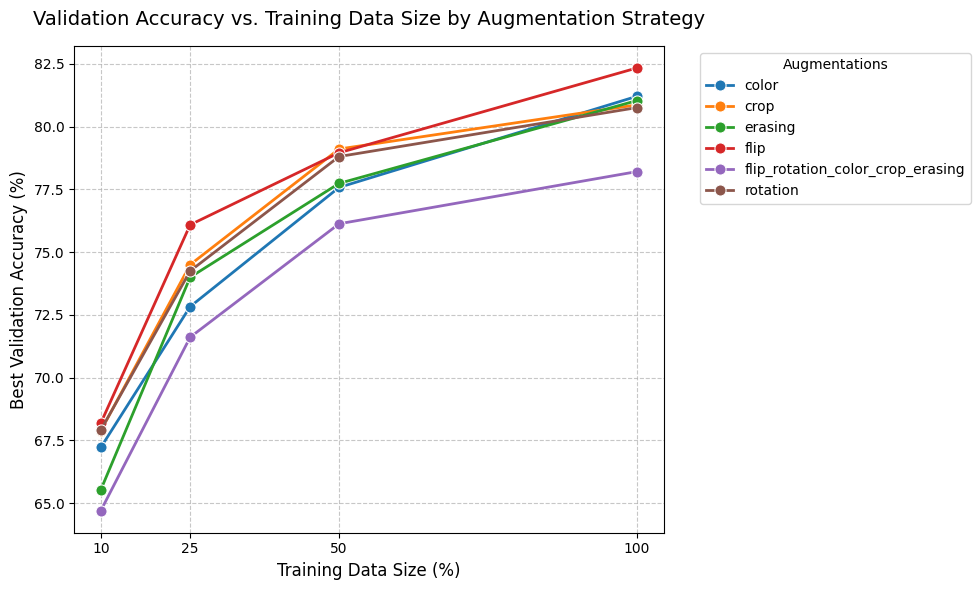


--- Raw Data (Sorted by Accuracy) ---
 params.percentage             params.augmentations  metrics.best_val_accuracy
             100.0                             flip                      82.34
             100.0                            color                      81.21
             100.0                          erasing                      81.04
             100.0                             crop                      80.87
             100.0                         rotation                      80.76
              50.0                             crop                      79.11
              50.0                             flip                      78.96
              50.0                         rotation                      78.81
             100.0 flip_rotation_color_crop_erasing                      78.21
              50.0                          erasing                      77.74
              50.0                            color                      77.58
             

In [9]:
from google.colab import drive
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reconnect to Google Drive (This is the critical step after a restart!)
drive.mount('/content/drive', force_remount=True)
# 2. Point MLflow back to your Drive directory
mlflow_dir = '/content/drive/MyDrive/CIFAR10_MLflow_Experiments'
mlflow.set_tracking_uri(f"file://{mlflow_dir}")

# 3. Query the experiment
experiment_name = "CIFAR10_Augmentation_Combinations"
experiment = mlflow.get_experiment_by_name(experiment_name)

if experiment is None:
    print(f"Could not find experiment: {experiment_name}.")
    print("Please double-check that your Drive is mounted and the folder 'CIFAR10_MLflow_Experiments' exists in your MyDrive root.")
else:
    print(f"Successfully found experiment. Fetching data...")

    # Fetch all runs as a Pandas DataFrame
    df = mlflow.search_runs([experiment.experiment_id])

    # Clean and filter the data
    df = df[df['status'] == 'FINISHED']

    # Extract only the columns we care about
    plot_df = df[['params.percentage', 'params.augmentations', 'metrics.best_val_accuracy']].copy()

    # MLflow saves parameters as strings, so we cast them back to floats
    plot_df['params.percentage'] = plot_df['params.percentage'].astype(float) * 100
    plot_df['metrics.best_val_accuracy'] = plot_df['metrics.best_val_accuracy'].astype(float)

    # Sort the data
    plot_df = plot_df.sort_values(by=['params.augmentations', 'params.percentage'])

    # Generate the visualization
    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=plot_df,
        x='params.percentage',
        y='metrics.best_val_accuracy',
        hue='params.augmentations',
        marker='o',
        linewidth=2,
        markersize=8
    )

    plt.title('Validation Accuracy vs. Training Data Size by Augmentation Strategy', fontsize=14, pad=15)
    plt.xlabel('Training Data Size (%)', fontsize=12)
    plt.ylabel('Best Validation Accuracy (%)', fontsize=12)

    plt.xticks([10, 25, 50, 100])
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Augmentations', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    plt.show()

    print("\n--- Raw Data (Sorted by Accuracy) ---")
    print(plot_df.sort_values(by='metrics.best_val_accuracy', ascending=False).to_string(index=False))

In [8]:
#do not run this code
#only run when drive refuses to mount
import os
from google.colab import drive

# 1. Forcefully unmount just in case it's partially attached
!fusermount -u /content/drive 2>/dev/null

# 2. Completely delete the corrupted local mount folder
!rm -rf /content/drive

# 3. Recreate a completely fresh, empty mount point
!mkdir /content/drive

# 4. Mount your Drive normally
drive.mount('/content/drive')

Mounted at /content/drive
